**📌 Project Domain**

Domain: Bioinformatika dan Kedokteran

Presisi Topik: Prediksi klasifikasi mutasi genetik dari teks medis untuk mendukung diagnosis dan pengobatan kanker.

**❗ Problem Statements**

Mutasi genetik berperan penting dalam berbagai jenis kanker. Namun, mengklasifikasikan mutasi berdasarkan teks klinis merupakan proses manual yang memakan waktu dan rentan kesalahan. Diperlukan model otomatis yang mampu mengklasifikasikan mutasi berdasarkan informasi gen, variasi, dan deskripsi klinis.

**🎯 Goals**

1.   Mengembangkan model deep learning berbasis RNN (LSTM) untuk memprediksi    kelas mutasi genetik dari teks klinis.
2.   Menerapkan model dalam aplikasi web yang dapat digunakan oleh profesional medis.



**💡 Solution Statements**

1.   Dataset diolah untuk mengekstrak informasi dari fitur Gene, Variation, dan Text.
2.   Data teks dikonversi ke bentuk numerik dengan tokenizer dan padding.
3.   RNN (LSTM) digunakan untuk menangkap informasi urutan dari teks medis.
4.   Model akan disimpan, dioptimalkan, dan digunakan dalam aplikasi Streamlit untuk simulasi prediksi.



**🧾 Data Understanding**

**Import Data dari Kaggle**

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"cctvwilayah4","key":"e32da349655a1719e8661e04304eb075"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [6]:
!kaggle datasets download -d altruistdelhite04/gold-price-data


Dataset URL: https://www.kaggle.com/datasets/altruistdelhite04/gold-price-data
License(s): unknown


In [7]:
!mkdir crop-recommendation-dataset
!unzip gold-price-data.zip -d crop-recommendation-dataset
!ls crop-recommendation-dataset

Archive:  gold-price-data.zip
  inflating: crop-recommendation-dataset/gld_price_data.csv  
gld_price_data.csv



**Import Library yang dibutuhkan**

In [8]:
# Library untuk manipulasi tanggal dan waktu
import datetime

# Library untuk manipulasi data
import numpy as np
import pandas as pd

# Library untuk Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

# Library untuk visualisasi
import matplotlib.pyplot as plt
import matplotlib.dates as mdate
import seaborn as sns

# Library untuk preprocessing dan evaluasi model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from datetime import datetime, timedelta




## Exploratory Data Analysis

In [48]:
data = pd.read_csv('/content/crop-recommendation-dataset/gld_price_data.csv')


In [49]:
data.head()



,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [50]:
data.tail()


,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [51]:

data.shape


(2290, 6)

In [52]:


data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [53]:


data.describe()



,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [54]:


data.duplicated().sum()



np.int64(0)

In [55]:
data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [56]:
data['Date'] = pd.to_datetime(data['Date'])

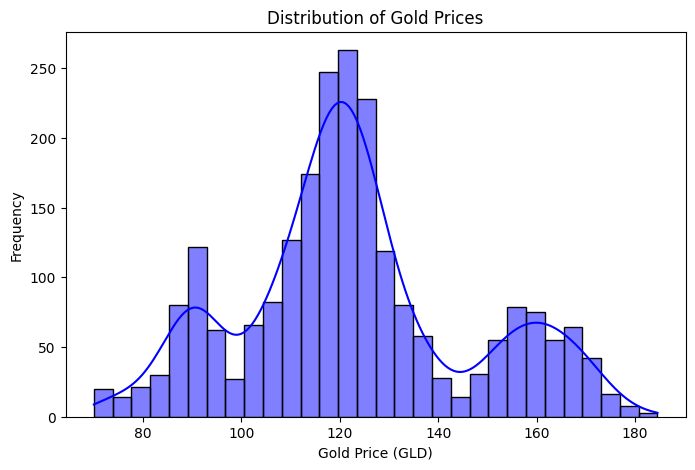

In [ ]:

plt.figure(figsize=(8, 5))
sns.histplot(data['GLD'], bins=30, kde=True, color='blue')
plt.xlabel('Gold Price (GLD)')
plt.ylabel('Frequency')
plt.title('Distribution of Gold Prices')
plt.show()



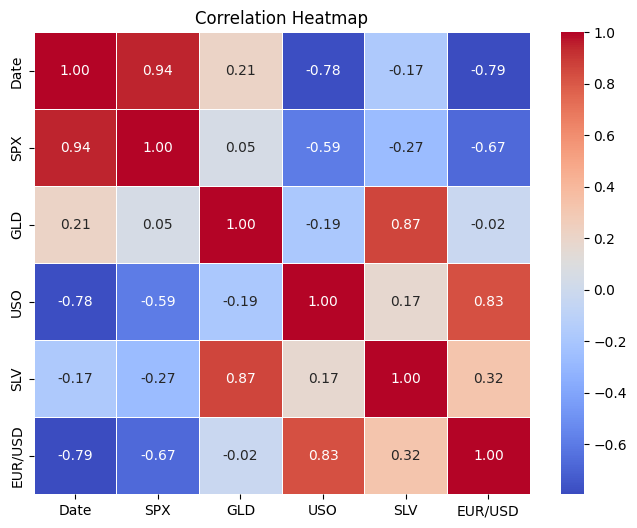

In [57]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

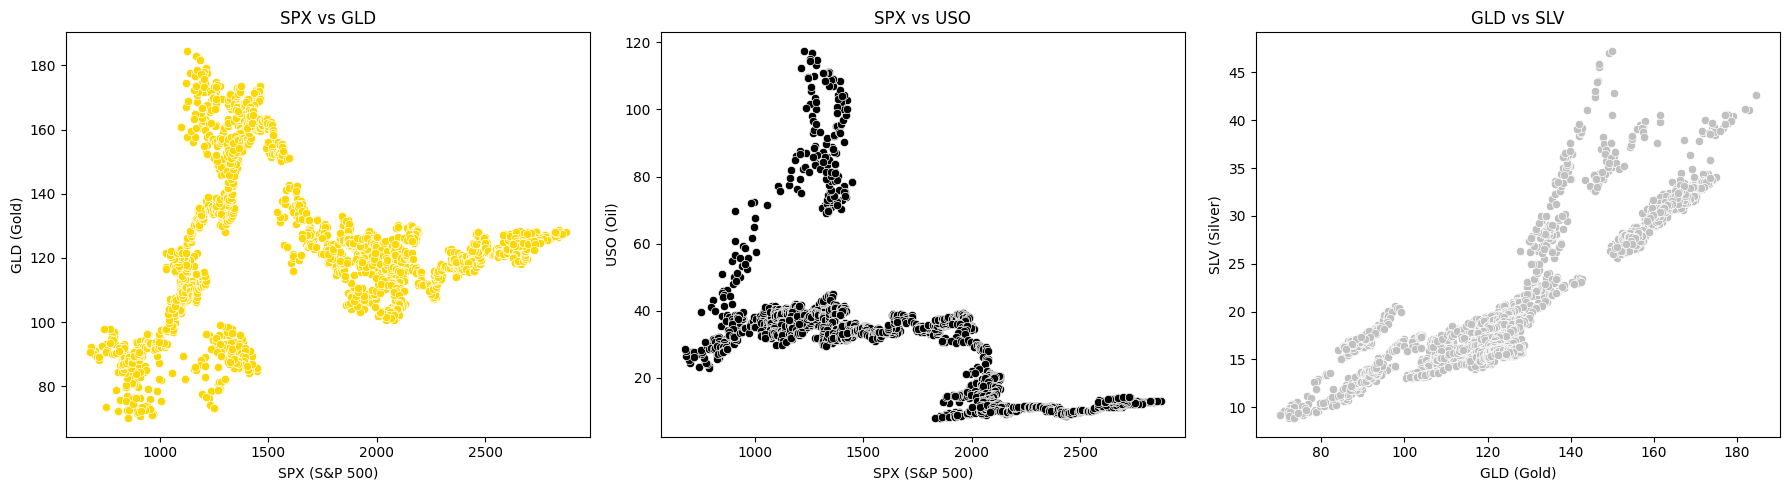

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SPX vs GLD
sns.scatterplot(x=data['SPX'], y=data['GLD'], ax=axes[0], color='gold')
axes[0].set_title('SPX vs GLD')
axes[0].set_xlabel('SPX (S&P 500)')
axes[0].set_ylabel('GLD (Gold)')

# SPX vs USO
sns.scatterplot(x=data['SPX'], y=data['USO'], ax=axes[1], color='black')
axes[1].set_title('SPX vs USO')
axes[1].set_xlabel('SPX (S&P 500)')
axes[1].set_ylabel('USO (Oil)')

# GLD vs SLV
sns.scatterplot(x=data['GLD'], y=data['SLV'], ax=axes[2], color='silver')
axes[2].set_title('GLD vs SLV')
axes[2].set_xlabel('GLD (Gold)')
axes[2].set_ylabel('SLV (Silver)')

plt.tight_layout()
plt.show()



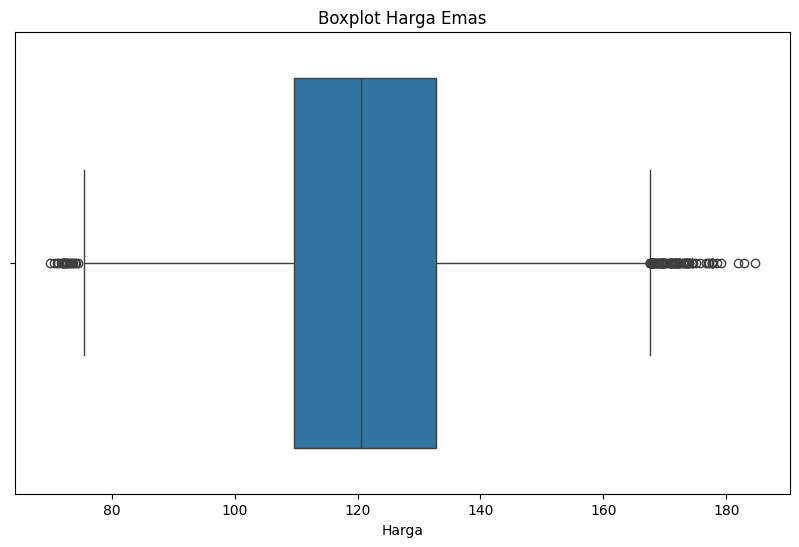

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['GLD'])
plt.title('Boxplot Harga Emas')
plt.xlabel('Harga')
plt.show()


In [60]:
data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099


**DATA PREPARATION**

In [68]:
# 1. Tetapkan nilai look_back
look_back = 60

In [69]:
# 2. Load data
data2 = data[['GLD']].values  #ambil kolom harga penutupan

In [70]:
# 3. Persiapan Data
X_train, X_test, y_train, y_test, scaler = prepare_data(data, look_back)

**MODELLING**

In [85]:
#Definisikan Model LSTM
def create_lstm_model(look_back):
    model = Sequential([
        Input(shape=(look_back, 1)),
        LSTM(units=50, return_sequences=True),
        Dropout(0.2),

        LSTM(units=50, return_sequences=True),
        Dropout(0.2),

        LSTM(units=50),
        Dropout(0.2),

        Dense(units=1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    return model

In [86]:
#Buat dan ringkas model
model = create_lstm_model(look_back)
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
#Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

#Training
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0434 - mean_absolute_error: 0.1453 - val_loss: 0.0011 - val_mean_absolute_error: 0.0265
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - loss: 0.0053 - mean_absolute_error: 0.0539 - val_loss: 0.0010 - val_mean_absolute_error: 0.0249
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0045 - mean_absolute_error: 0.0509 - val_loss: 9.3284e-04 - val_mean_absolute_error: 0.0236
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - loss: 0.0038 - mean_absolute_error: 0.0467 - val_loss: 0.0014 - val_mean_absolute_error: 0.0304
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0040 - mean_absolute_error: 0.0486 - val_loss: 0.0016 - val_mean_absolute_error: 0.0324
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0040 - mean_absolute_error: 0.0482 - val_loss: 0.0011 - val_mean_absolute_error: 0.0267
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0041 - mean_absolute_error: 0

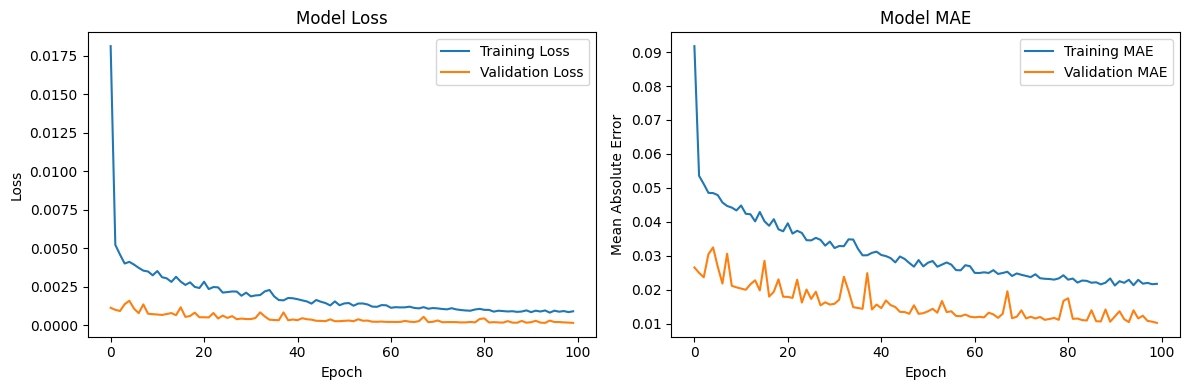

In [88]:
#Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.tight_layout()
plt.show()

**Evaluation**

In [89]:
# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 394ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


In [90]:
# Inverse transform
train_predict = scaler.inverse_transform(train_predict)
y_train_inv = scaler.inverse_transform([y_train])
test_predict = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform([y_test])

In [91]:
# Calculate metrics
metrics = {
    'Train RMSE (IDR)': np.sqrt(mean_squared_error(y_train_inv.T * exchange_rate, train_predict_idr)),
    'Test RMSE (IDR)': np.sqrt(mean_squared_error(y_test_inv.T * exchange_rate, test_predict_idr)),
    'Train MAE (IDR)': mean_absolute_error(y_train_inv.T * exchange_rate, train_predict_idr),
    'Test MAE (IDR)': mean_absolute_error(y_test_inv.T * exchange_rate, test_predict_idr),
    'Train R²': r2_score(y_train_inv.T, train_predict),
    'Test R²': r2_score(y_test_inv.T, test_predict)
}


In [92]:
# Display metrics
for metric, value in metrics.items():
    if 'IDR' in metric:
        print(f"{metric}: Rp {value:,.2f}")
    else:
        print(f"{metric}: {value:.4f}")

Train RMSE (IDR): Rp 37,003.17
Test RMSE (IDR): Rp 22,220.33
Train MAE (IDR): Rp 26,835.95
Test MAE (IDR): Rp 17,453.34
Train R²: 0.9936
Test R²: 0.9329


**MODEL SIMULATION**

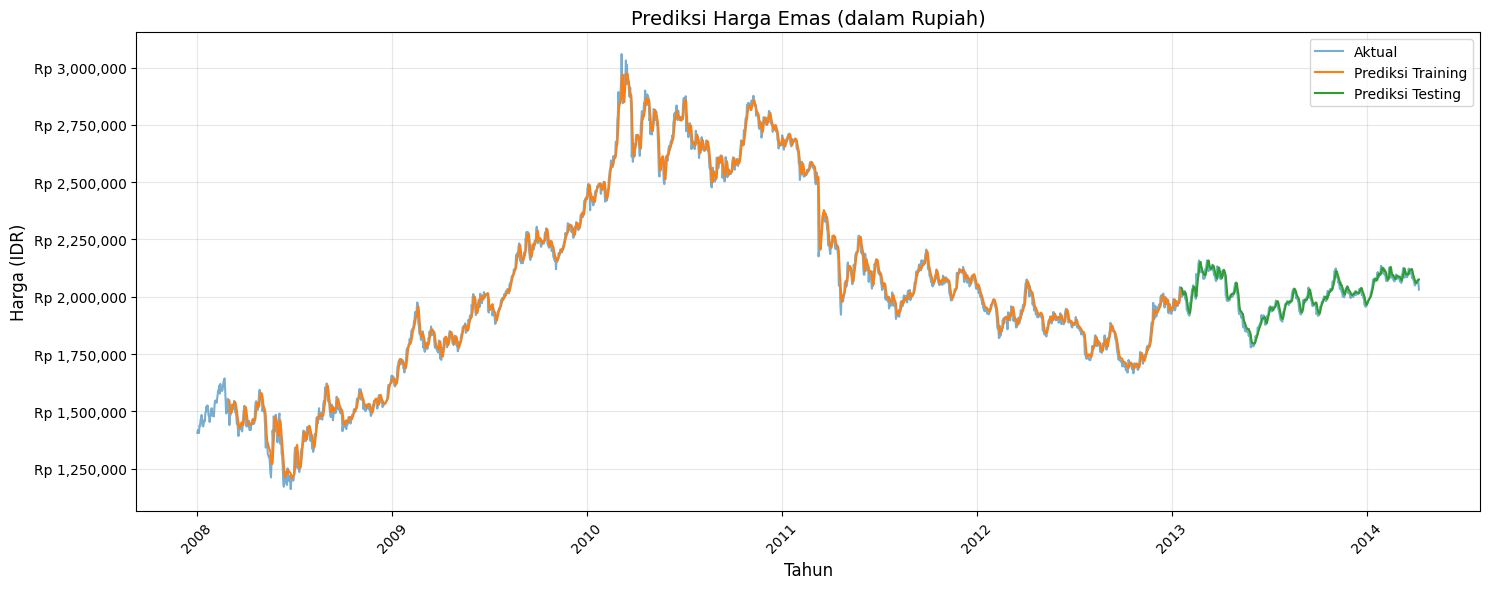


Statistik Harga Emas (dalam Rupiah):
Harga Tertinggi: Rp 3,059,394.59
Harga Terendah: Rp 1,160,180.00
Harga Rata-rata: Rp 2,034,174.67


In [93]:
# Konversi ke Rupiah (asumsikan data awal dalam USD)
exchange_rate = 16574  # Sesuaikan dengan kurs USD to IDR terkini
train_predict_idr = train_predict * exchange_rate
test_predict_idr = test_predict * exchange_rate
actual_prices_idr = data['GLD'].values * exchange_rate

# Plot predictions dengan format Rupiah dan tahun
plt.figure(figsize=(15, 6))

# Konversi index ke tahun
years = pd.date_range(start=data['Date'].iloc[0], periods=len(data), freq='D')

# Plot data aktual dan prediksi
plt.plot(years, actual_prices_idr, label='Aktual', alpha=0.6)
plt.plot(years[look_back:len(train_predict_idr) + look_back],
         train_predict_idr, label='Prediksi Training')
plt.plot(years[len(train_predict_idr) + look_back:],
         test_predict_idr, label='Prediksi Testing')


# Formatting
plt.title('Prediksi Harga Emas (dalam Rupiah)', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Harga (IDR)', fontsize=12)
plt.legend(fontsize=10)

# Format y-axis dalam jutaan rupiah
def format_idr(x, p):
    return f'Rp {x:,.0f}'
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_idr))

# Rotate x-axis labels
plt.xticks(rotation=45)

# Grid
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

# Tambahan: Print beberapa statistik dalam Rupiah
print("\nStatistik Harga Emas (dalam Rupiah):")
print(f"Harga Tertinggi: Rp {np.max(actual_prices_idr):,.2f}")
print(f"Harga Terendah: Rp {np.min(actual_prices_idr):,.2f}")
print(f"Harga Rata-rata: Rp {np.mean(actual_prices_idr):,.2f}")

In [94]:
metrics = {

    'Train R²': r2_score(y_train_inv.T, train_predict),
    'Test R²': r2_score(y_test_inv.T, test_predict)
}

# Display metrics with improved formatting
print("\nModel Evaluation Metrics:")
for metric, value in metrics.items():
    if 'RMSE' in metric or 'MAE' in metric:
        print(f"{metric}: Rp {value:,.2f}")
    elif 'R²' in metric:
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")



Model Evaluation Metrics:
Train R²: 0.9936
Test R²: 0.9329


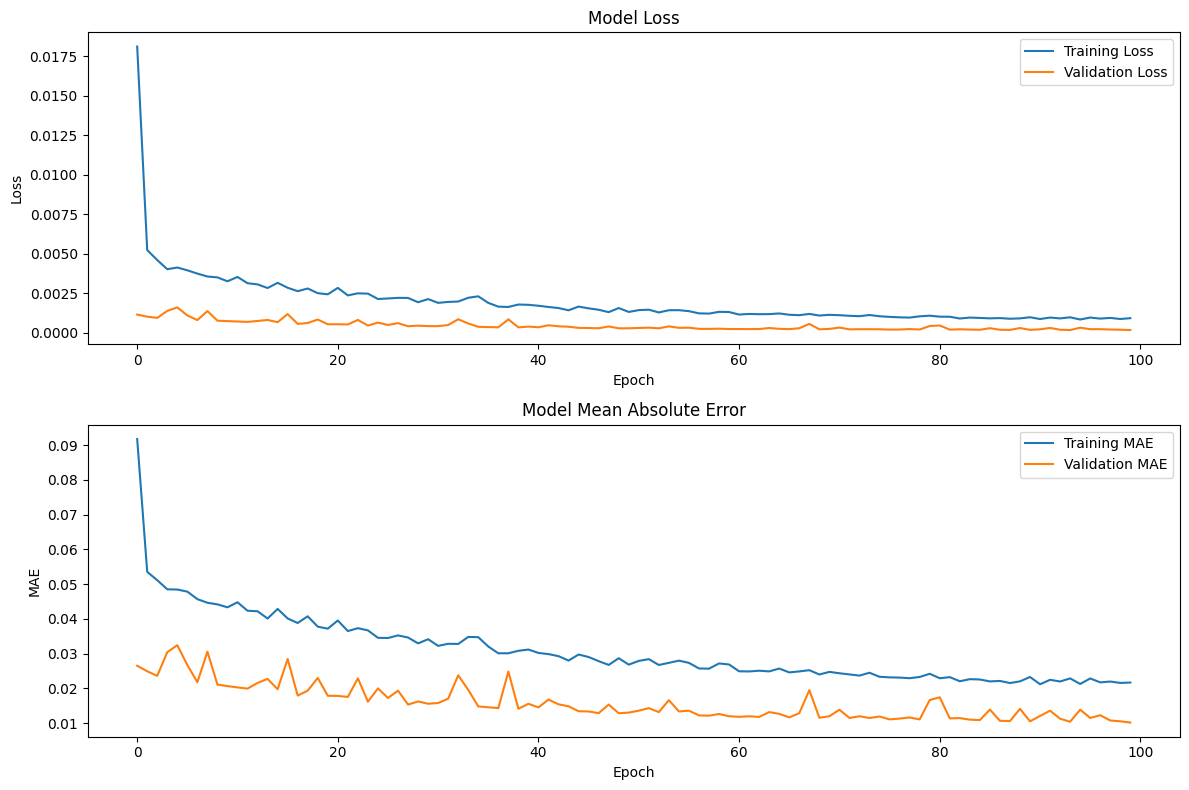

In [95]:
plt.figure(figsize=(12, 8))

# Loss
plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# MAE (Mean Absolute Error)
plt.subplot(2, 1, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()


plt.tight_layout()
plt.show()


**SAVE MODEL**

In [96]:
#KONVERSI MODEL KE TFLITE
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Aktifkan variabel resource
converter.experimental_enable_resource_variables = True
# Tetapkan operasi yang didukung dan nonaktifkan penurunan operasi daftar tensor
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()

# Simpan model TFLite
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpr6edzvrh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 1), dtype=tf.float32, name='keras_tensor_56')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132878104208080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132878104210576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132878104211152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132878104213072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132878104211728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132878104212304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132878104205200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132878104213648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132878104213264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132878104214992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132878104214608: 

In [97]:
import joblib

joblib.dump(scaler, 'scaler.pkl')




['scaler.pkl']